# UFC Fight Outcome Prediction — Machine Learning Model

**Goal:** Predict whether the Red-corner fighter wins a bout using only pre-fight differential statistics (Red minus Blue) to eliminate data leakage.

**Key design choice — differential features:** feeding raw per-fighter stats would let a tree memorise individual fighters. By subtracting Blue from Red we encode *relative* advantage, which generalises across the roster.

---

## 1. Setup & Feature Engineering

We load the raw tables from `ufc.db` and derive nine differential features. Three of them (`win_pct_diff`, `finish_rate_diff`, `days_rest_diff`) require a rolling window over fight history — we compute them with a `shift(1)` trick so only *prior* bouts contribute, making the features genuinely pre-fight.

The six physical / style features (`reach`, `height`, `age`, `slpm`, `str_acc`, `td_avg`) come from the `fighters` table.  Those averages are career-wide, which introduces mild leakage for fighters who competed after 2021 — a known limitation documented below.

In [1]:

import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.pipeline          import Pipeline
from sklearn.impute            import SimpleImputer
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection   import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics           import (
    roc_auc_score, accuracy_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.calibration       import calibration_curve

warnings.filterwarnings("ignore")
%matplotlib inline

BG = "#F9F9F9"
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})

# ── load tables ───────────────────────────────────────────────────────────────
conn = sqlite3.connect("ufc.db")
fighters   = pd.read_sql("SELECT * FROM fighters",   conn)
events     = pd.read_sql("SELECT * FROM events",     conn)
bouts      = pd.read_sql("SELECT * FROM bouts",      conn)
conn.close()

print("Tables loaded.")
for name, df in [("fighters", fighters), ("events", events), ("bouts", bouts)]:
    print(f"  {name:<10} {df.shape[0]:>6,} rows")


Tables loaded.
  fighters    3,596 rows
  events        555 rows
  bouts       6,014 rows


In [2]:

# ── Step 1: merge event dates onto bouts ─────────────────────────────────────
bouts_d = bouts.merge(events[["event_id", "event_date"]], on="event_id", how="left")
decisive = bouts_d[bouts_d["winner"].isin(["Red", "Blue"])].copy()

print(f"Decisive bouts (Red or Blue winner): {len(decisive):,}")
print(f"Class balance:")
vc = decisive["winner"].value_counts()
for k, v in vc.items():
    print(f"  {k}: {v:,}  ({v/len(decisive)*100:.1f}%)")
print()
print(f"Naive baseline accuracy (always predict Red): {vc['Red']/len(decisive)*100:.1f}%")


Decisive bouts (Red or Blue winner): 5,903
Class balance:
  Red: 3,980  (67.4%)
  Blue: 1,923  (32.6%)

Naive baseline accuracy (always predict Red): 67.4%


In [3]:

# ── Step 2: rolling win-rate and finish-rate (no leakage) ─────────────────────
# Build one row per (fighter, fight) ordered by date, then shift cumulative
# totals by 1 so the current fight is excluded from its own record.

FINISH_METHODS = {"KO/TKO", "Submission", "TKO - Doctor's Stoppage"}

rows = []
for _, b in decisive.iterrows():
    for corner, name_col in [("Red", "r_fighter_name"), ("Blue", "b_fighter_name")]:
        rows.append({
            "fighter":  b[name_col],
            "date":     b["event_date"],
            "won":      1 if b["winner"] == corner else 0,
            "finished": 1 if (b["winner"] == corner
                              and b["win_by"] in FINISH_METHODS) else 0,
        })

hist = (
    pd.DataFrame(rows)
    .sort_values(["fighter", "date"])
    .reset_index(drop=True)
)

# Cumulative sums up to and including this fight
g = hist.groupby("fighter", sort=False)
hist["cum_wins"]     = g["won"].cumsum()
hist["cum_fights"]   = g.cumcount() + 1
hist["cum_finishes"] = g["finished"].cumsum()

# Shift by 1 → values BEFORE this fight
hist["prior_wins"]     = g["cum_wins"].shift(1).fillna(0)
hist["prior_fights"]   = g["cum_fights"].shift(1).fillna(0)
hist["prior_finishes"] = g["cum_finishes"].shift(1).fillna(0)

# Rates: default 0.5 win-pct / 0.0 finish-rate on debut
hist["win_pct"]     = np.where(hist["prior_fights"] > 0,
                               hist["prior_wins"] / hist["prior_fights"], 0.5)
hist["finish_rate"] = np.where(hist["prior_wins"] > 0,
                               hist["prior_finishes"] / hist["prior_wins"], 0.0)

# Days since last fight (365 default for debut)
hist["prev_date"]  = g["date"].shift(1)
hist["days_rest"]  = (
    pd.to_datetime(hist["date"]) - pd.to_datetime(hist["prev_date"])
).dt.days.fillna(365)

print("Rolling stats computed.")
print(hist[["fighter","date","win_pct","finish_rate","days_rest"]].head(6).to_string(index=False))


Rolling stats computed.
       fighter       date  win_pct  finish_rate  days_rest
    Aalon Cruz 2020-02-29      0.5          0.0      365.0
    Aalon Cruz 2021-03-06      0.0          0.0      371.0
   Aaron Brink 2000-11-17      0.5          0.0      365.0
Aaron Phillips 2014-05-24      0.5          0.0      365.0
Aaron Phillips 2014-08-23      0.0          0.0       91.0
Aaron Phillips 2020-07-15      0.0          0.0     2153.0


In [4]:

# ── Step 3: merge rolling stats back onto decisive bouts ──────────────────────
r_hist = (hist[["fighter","date","win_pct","finish_rate","days_rest"]]
          .rename(columns={
              "fighter":     "r_fighter_name",
              "date":        "event_date",
              "win_pct":     "r_win_pct",
              "finish_rate": "r_finish_rate",
              "days_rest":   "r_days_rest",
          }))
b_hist = (hist[["fighter","date","win_pct","finish_rate","days_rest"]]
          .rename(columns={
              "fighter":     "b_fighter_name",
              "date":        "event_date",
              "win_pct":     "b_win_pct",
              "finish_rate": "b_finish_rate",
              "days_rest":   "b_days_rest",
          }))

df = (decisive
      .merge(r_hist, on=["r_fighter_name", "event_date"], how="left")
      .merge(b_hist, on=["b_fighter_name", "event_date"], how="left"))

# ── Step 4: attach static fighter stats ──────────────────────────────────────
f_cols = ["fighter_name", "reach_cm", "height_cm", "dob", "slpm", "str_acc", "td_avg"]
f = fighters[f_cols].copy()

r_f = f.rename(columns={c: f"r_{c}" for c in f_cols if c != "fighter_name"})
r_f.rename(columns={"fighter_name": "r_fighter_name"}, inplace=True)
b_f = f.rename(columns={c: f"b_{c}" for c in f_cols if c != "fighter_name"})
b_f.rename(columns={"fighter_name": "b_fighter_name"}, inplace=True)

df = df.merge(r_f, on="r_fighter_name", how="left")
df = df.merge(b_f, on="b_fighter_name", how="left")

# ── Step 5: compute age at fight time ─────────────────────────────────────────
for corner in ("r", "b"):
    df[f"{corner}_age"] = (
        (pd.to_datetime(df["event_date"]) - pd.to_datetime(df[f"{corner}_dob"]))
        .dt.days / 365.25
    )

# ── Step 6: build differential features ──────────────────────────────────────
df["reach_diff"]       = df["r_reach_cm"]    - df["b_reach_cm"]
df["height_diff"]      = df["r_height_cm"]   - df["b_height_cm"]
df["age_diff"]         = df["r_age"]         - df["b_age"]
df["win_pct_diff"]     = df["r_win_pct"]     - df["b_win_pct"]
df["finish_rate_diff"] = df["r_finish_rate"] - df["b_finish_rate"]
df["slpm_diff"]        = df["r_slpm"]        - df["b_slpm"]
df["str_acc_diff"]     = df["r_str_acc"]     - df["b_str_acc"]
df["td_avg_diff"]      = df["r_td_avg"]      - df["b_td_avg"]
df["days_rest_diff"]   = df["r_days_rest"]   - df["b_days_rest"]

FEATURES = [
    "reach_diff", "height_diff", "age_diff",
    "win_pct_diff", "finish_rate_diff",
    "slpm_diff", "str_acc_diff", "td_avg_diff",
    "days_rest_diff",
]

X = df[FEATURES].copy()
y = (df["winner"] == "Red").astype(int)

print(f"Modeling dataset:  {X.shape[0]:,} rows  x  {X.shape[1]} features")
print(f"Missing values per feature:")
print(X.isna().sum().to_string())
print(f"\nTarget balance  →  Red win: {y.mean()*100:.1f}%  |  Blue win: {(1-y.mean())*100:.1f}%")


Modeling dataset:  6,207 rows  x  9 features
Missing values per feature:
reach_diff          1334
height_diff           16
age_diff             395
win_pct_diff           0
finish_rate_diff       0
slpm_diff              0
str_acc_diff           0
td_avg_diff            0
days_rest_diff         0

Target balance  →  Red win: 69.0%  |  Blue win: 31.0%


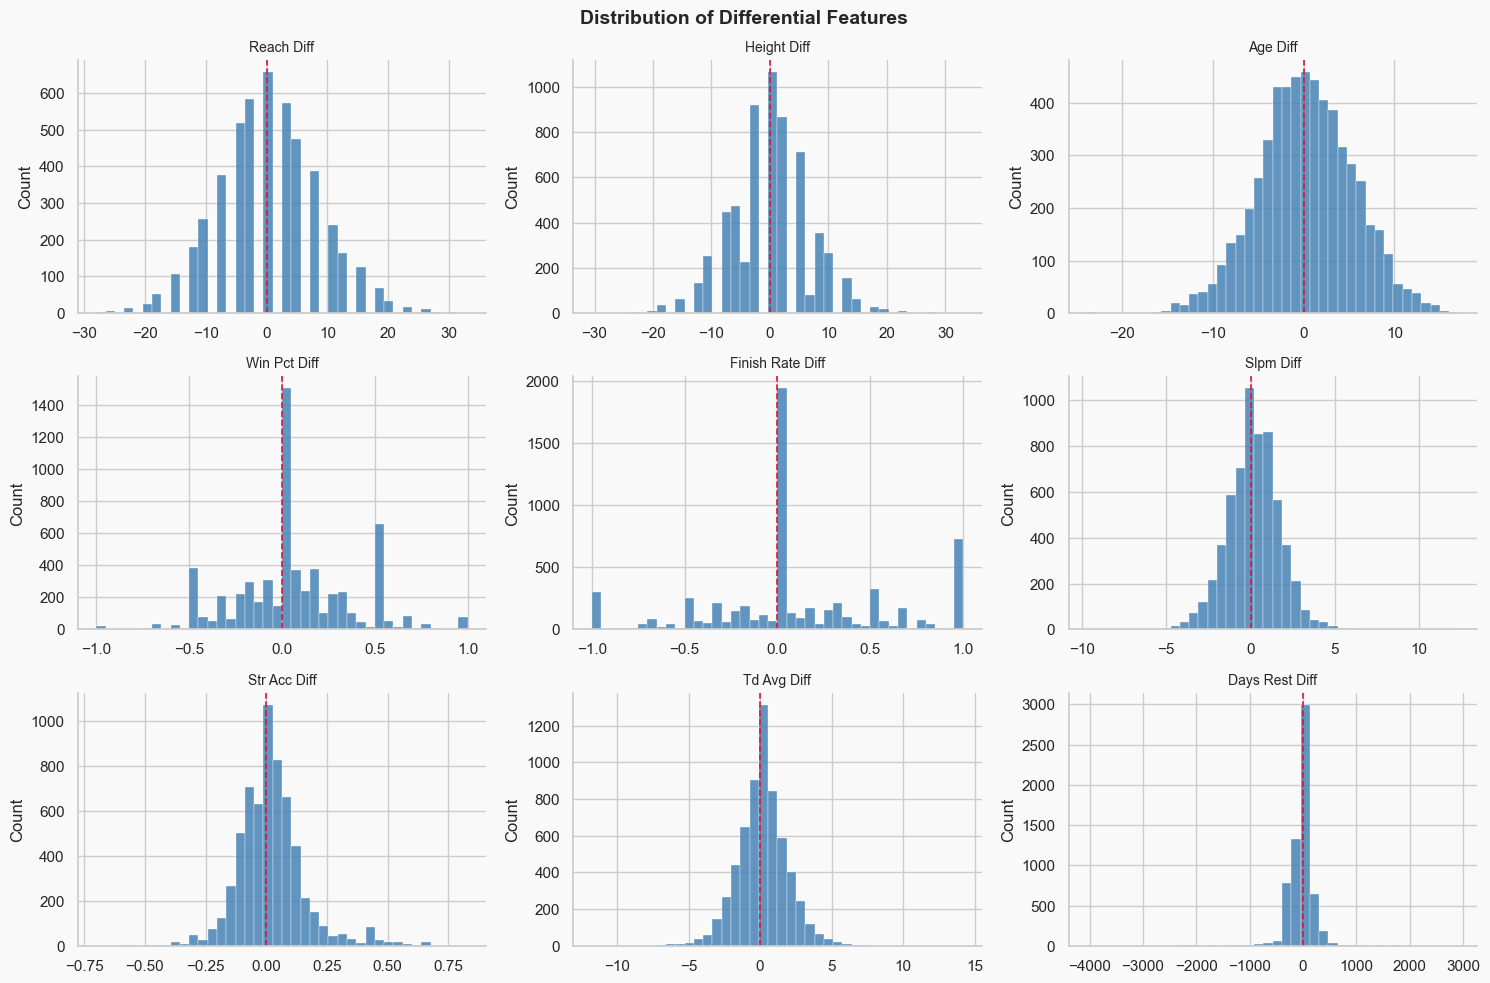

Feature correlations with target (Red wins = 1):
age_diff            -0.1711
days_rest_diff      -0.0435
finish_rate_diff    +0.0248
height_diff         +0.0446
reach_diff          +0.0667
win_pct_diff        +0.0988
td_avg_diff         +0.1147
str_acc_diff        +0.1905
slpm_diff           +0.2496


In [5]:

# ── Feature distributions at a glance ────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle("Distribution of Differential Features", fontsize=14, fontweight="bold")

for ax, feat in zip(axes.flat, FEATURES):
    vals = X[feat].dropna()
    ax.hist(vals, bins=40, color="steelblue", edgecolor="white", linewidth=0.3, alpha=0.85)
    ax.axvline(0, color="crimson", linewidth=1.2, linestyle="--")
    ax.set_title(feat.replace("_", " ").title(), fontsize=10)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("fig_model_features.png", dpi=130, bbox_inches="tight")
plt.show()

# Correlation with target
corrs = pd.Series(
    {f: X[f].dropna().corr(y[X[f].notna()]) for f in FEATURES},
    name="corr_with_red_win"
).sort_values()

print("Feature correlations with target (Red wins = 1):")
print(corrs.apply(lambda x: f"{x:+.4f}").to_string())


---
## 2. Baseline Model — Logistic Regression

A simple linear classifier gives us an interpretable baseline. We impute missing values with the column mean and scale features to unit variance before fitting.  Because 67.4% of bouts are won by the Red corner, **raw accuracy alone is a misleading metric** — a model that always predicts Red scores 67% without learning anything. We therefore focus on **ROC-AUC**, which measures discriminative ability independent of the prediction threshold.

In [6]:

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("scale",  StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, random_state=42)),
])

lr_auc  = cross_val_score(lr_pipe, X, y, cv=CV, scoring="roc_auc",  n_jobs=-1)
lr_acc  = cross_val_score(lr_pipe, X, y, cv=CV, scoring="accuracy", n_jobs=-1)

print("Logistic Regression — 5-Fold CV")
print(f"  ROC-AUC : {lr_auc.mean():.4f}  ±  {lr_auc.std():.4f}")
print(f"  Accuracy: {lr_acc.mean():.4f}  ±  {lr_acc.std():.4f}")
print(f"  (Naive baseline accuracy = 67.4%)")


Logistic Regression — 5-Fold CV
  ROC-AUC : 0.6970  ±  0.0167
  Accuracy: 0.7036  ±  0.0059
  (Naive baseline accuracy = 67.4%)


---
## 3. Random Forest

An ensemble of decision trees can capture non-linear interactions between features — for example, a reach advantage only matters if the fighter also has the striking accuracy to exploit it. We limit tree depth slightly to reduce overfitting on this relatively small dataset.

In [7]:

rf_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("clf",    RandomForestClassifier(
                   n_estimators=300,
                   max_depth=8,
                   min_samples_leaf=10,
                   random_state=42,
                   n_jobs=-1,
               )),
])

rf_auc  = cross_val_score(rf_pipe, X, y, cv=CV, scoring="roc_auc",  n_jobs=-1)
rf_acc  = cross_val_score(rf_pipe, X, y, cv=CV, scoring="accuracy", n_jobs=-1)

print("Random Forest — 5-Fold CV")
print(f"  ROC-AUC : {rf_auc.mean():.4f}  ±  {rf_auc.std():.4f}")
print(f"  Accuracy: {rf_acc.mean():.4f}  ±  {rf_acc.std():.4f}")


Random Forest — 5-Fold CV
  ROC-AUC : 0.7270  ±  0.0154
  Accuracy: 0.7071  ±  0.0064


---
## 4. Gradient Boosting

Gradient Boosting fits trees sequentially, each one correcting the residual errors of the previous. It typically outperforms a single Random Forest on tabular data but is more sensitive to hyperparameters. We use a low learning rate with more trees for stability.

In [8]:

gb_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("clf",    GradientBoostingClassifier(
                   n_estimators=300,
                   learning_rate=0.05,
                   max_depth=3,
                   subsample=0.8,
                   random_state=42,
               )),
])

gb_auc  = cross_val_score(gb_pipe, X, y, cv=CV, scoring="roc_auc",  n_jobs=-1)
gb_acc  = cross_val_score(gb_pipe, X, y, cv=CV, scoring="accuracy", n_jobs=-1)

print("Gradient Boosting — 5-Fold CV")
print(f"  ROC-AUC : {gb_auc.mean():.4f}  ±  {gb_auc.std():.4f}")
print(f"  Accuracy: {gb_acc.mean():.4f}  ±  {gb_acc.std():.4f}")


Gradient Boosting — 5-Fold CV
  ROC-AUC : 0.7237  ±  0.0156
  Accuracy: 0.7010  ±  0.0074


---
## 5. Model Comparison

Side-by-side bar chart of mean ROC-AUC and accuracy across all three models, with ±1 standard deviation error bars from the 5-fold CV.

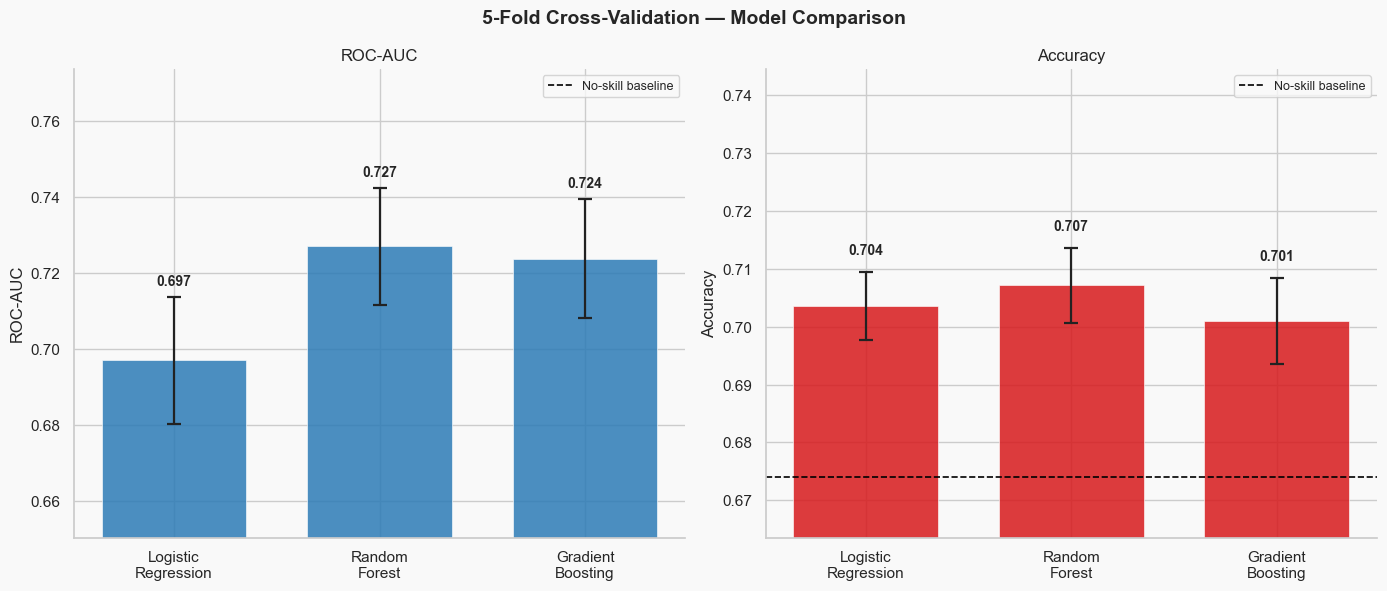


Summary table:
              Model  ROC-AUC (mean)  ROC-AUC (std)  Accuracy (mean)  Accuracy (std)
Logistic Regression          0.6970         0.0167           0.7036          0.0059
      Random Forest          0.7270         0.0154           0.7071          0.0064
  Gradient Boosting          0.7237         0.0156           0.7010          0.0074


In [9]:

results = {
    "Logistic\nRegression": {"auc": lr_auc, "acc": lr_acc},
    "Random\nForest":       {"auc": rf_auc, "acc": rf_acc},
    "Gradient\nBoosting":   {"auc": gb_auc, "acc": gb_acc},
}

model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.32

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("5-Fold Cross-Validation — Model Comparison",
             fontsize=14, fontweight="bold")

COLORS = {"auc": "#2C7BB6", "acc": "#D7191C"}

for ax, metric, ylabel, baseline in [
    (axes[0], "auc", "ROC-AUC",  0.5),
    (axes[1], "acc", "Accuracy", 0.674),
]:
    vals  = [results[m][metric].mean() for m in model_names]
    stds  = [results[m][metric].std()  for m in model_names]
    bars  = ax.bar(x, vals, width=width * 2.2,
                   color=COLORS[metric], edgecolor="white",
                   linewidth=0.5, alpha=0.85)
    ax.errorbar(x, vals, yerr=stds, fmt="none",
                color="#222", capsize=5, linewidth=1.6, capthick=1.6)
    ax.axhline(baseline, color="black", linestyle="--", linewidth=1.2,
               label="No-skill baseline")
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=9)

    lo = min(vals) - max(stds) - 0.03
    hi = max(vals) + max(stds) + 0.03
    ax.set_ylim(max(0, lo), min(1, hi))

    for bar, v, s in zip(bars, vals, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + s + 0.003,
                f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("fig_model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

print("\nSummary table:")
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "ROC-AUC (mean)":  [lr_auc.mean(), rf_auc.mean(), gb_auc.mean()],
    "ROC-AUC (std)":   [lr_auc.std(),  rf_auc.std(),  gb_auc.std()],
    "Accuracy (mean)": [lr_acc.mean(), rf_acc.mean(), gb_acc.mean()],
    "Accuracy (std)":  [lr_acc.std(),  rf_acc.std(),  gb_acc.std()],
}).round(4)
print(summary.to_string(index=False))


---
## 6. Best Model Deep Dive

We select the model with the highest mean ROC-AUC, refit it on the full dataset, and examine four diagnostic views:

1. **Feature importance** — which inputs drove predictions the most?
2. **ROC curve** — using out-of-fold predictions from 5-fold CV
3. **Confusion matrix** — normalised by true class
4. **Calibration plot** — are predicted probabilities reliable?

Best model: Random Forest


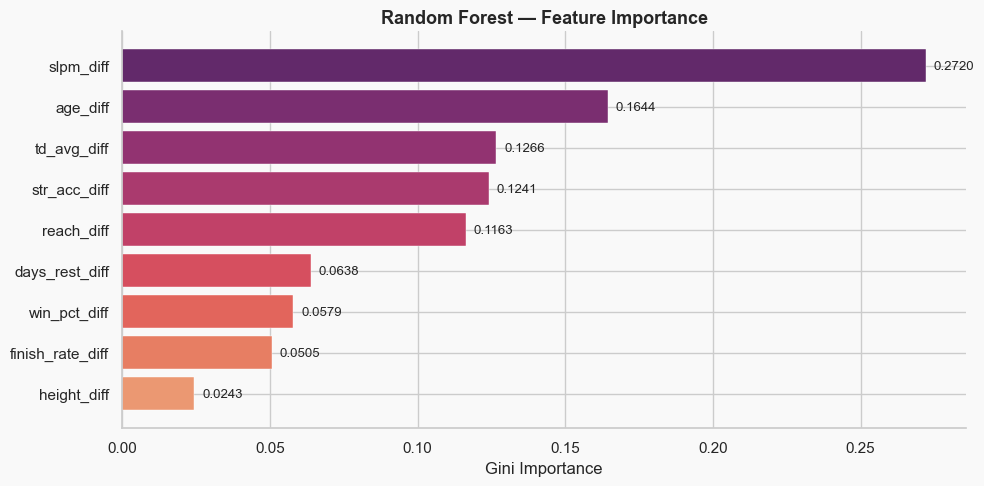

In [10]:

# ── Select best model by AUC ──────────────────────────────────────────────────
candidates = {
    "Logistic Regression": (lr_pipe, lr_auc.mean()),
    "Random Forest":       (rf_pipe, rf_auc.mean()),
    "Gradient Boosting":   (gb_pipe, gb_auc.mean()),
}
best_name, (best_pipe, _) = max(candidates.items(), key=lambda kv: kv[1][1])
print(f"Best model: {best_name}")

# Refit on full data for feature importance
imputer = SimpleImputer(strategy="mean")
X_imp   = imputer.fit_transform(X)

best_pipe.fit(X, y)
clf_fitted = best_pipe.named_steps["clf"]

# ── Feature importance ────────────────────────────────────────────────────────
if hasattr(clf_fitted, "feature_importances_"):
    importances = clf_fitted.feature_importances_
    imp_label   = "Gini Importance"
else:
    # Logistic Regression: use absolute coefficients (after scaling)
    importances = np.abs(clf_fitted.coef_[0])
    imp_label   = "|Coefficient|"

feat_imp = (
    pd.Series(importances, index=FEATURES)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors  = sns.color_palette("flare", len(feat_imp))
ax.barh(feat_imp.index, feat_imp.values,
        color=colors, edgecolor="white", linewidth=0.3)
ax.set_xlabel(imp_label)
ax.set_title(f"{best_name} — Feature Importance", fontsize=13, fontweight="bold")
for i, (feat, val) in enumerate(feat_imp.items()):
    ax.text(val + feat_imp.max() * 0.01, i,
            f"{val:.4f}", va="center", fontsize=9.5)
plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()


OOF ROC-AUC : 0.7265
OOF Accuracy: 0.7071


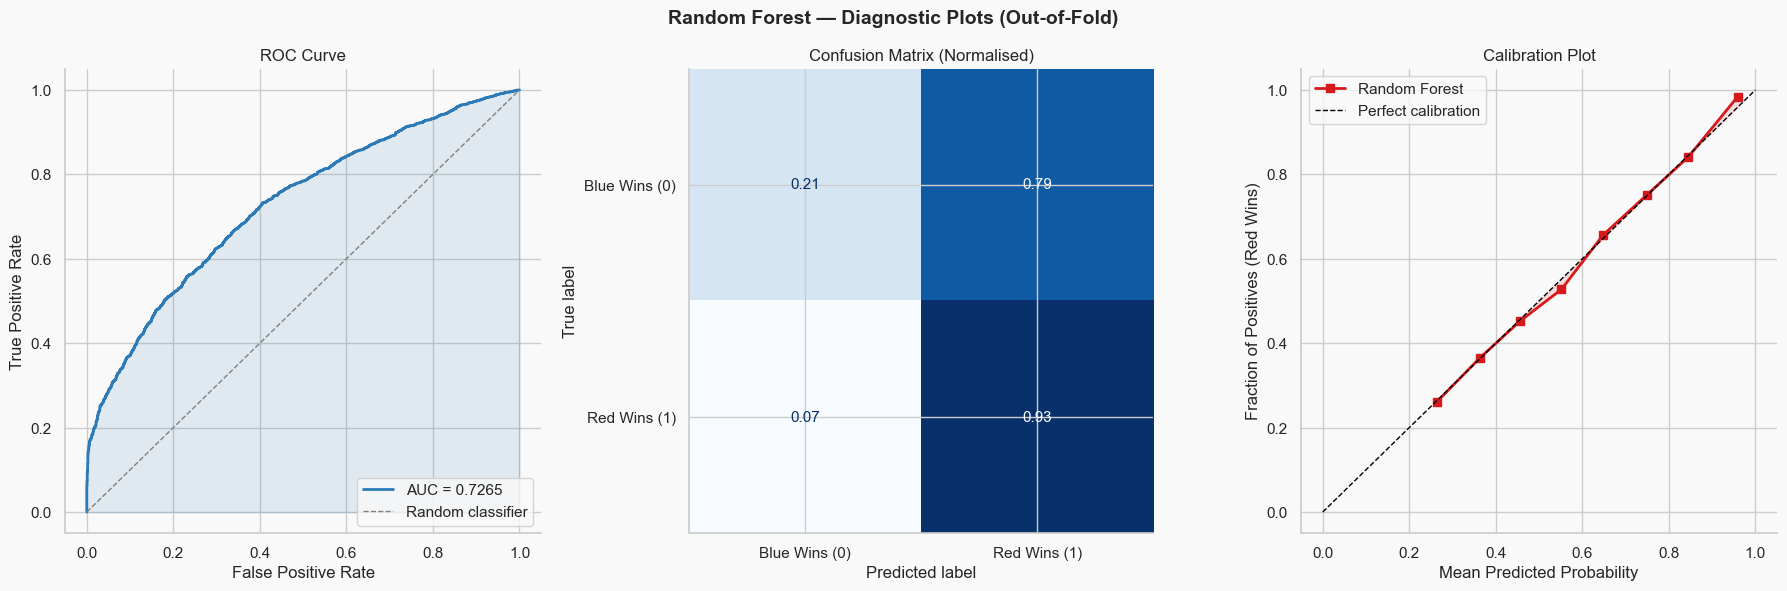

In [11]:

# ── Out-of-fold predictions for ROC + Calibration ─────────────────────────────
oof_proba = cross_val_predict(best_pipe, X, y, cv=CV,
                              method="predict_proba", n_jobs=-1)[:, 1]
oof_pred  = cross_val_predict(best_pipe, X, y, cv=CV,
                              method="predict",       n_jobs=-1)

oof_auc = roc_auc_score(y, oof_proba)
oof_acc = accuracy_score(y, oof_pred)
print(f"OOF ROC-AUC : {oof_auc:.4f}")
print(f"OOF Accuracy: {oof_acc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"{best_name} — Diagnostic Plots (Out-of-Fold)",
             fontsize=14, fontweight="bold")

# ── ROC curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y, oof_proba)
axes[0].plot(fpr, tpr, color="#2C7BB6", linewidth=2,
             label=f"AUC = {oof_auc:.4f}")
axes[0].plot([0, 1], [0, 1], color="grey", linestyle="--",
             linewidth=1, label="Random classifier")
axes[0].fill_between(fpr, tpr, alpha=0.12, color="#2C7BB6")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y, oof_pred, normalize="true")
disp = ConfusionMatrixDisplay(cm, display_labels=["Blue Wins (0)", "Red Wins (1)"])
disp.plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title("Confusion Matrix (Normalised)")
axes[1].set_facecolor(BG)

# ── Calibration plot ──────────────────────────────────────────────────────────
frac_pos, mean_pred = calibration_curve(y, oof_proba, n_bins=10, strategy="uniform")
axes[2].plot(mean_pred, frac_pos, "s-", color="#D7191C", linewidth=2,
             label=best_name)
axes[2].plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
axes[2].fill_between(mean_pred, frac_pos, mean_pred,
                     alpha=0.12, color="#D7191C")
axes[2].set_xlabel("Mean Predicted Probability")
axes[2].set_ylabel("Fraction of Positives (Red Wins)")
axes[2].set_title("Calibration Plot")
axes[2].legend(loc="upper left")

plt.tight_layout()
plt.savefig("fig_deep_dive.png", dpi=130, bbox_inches="tight")
plt.show()


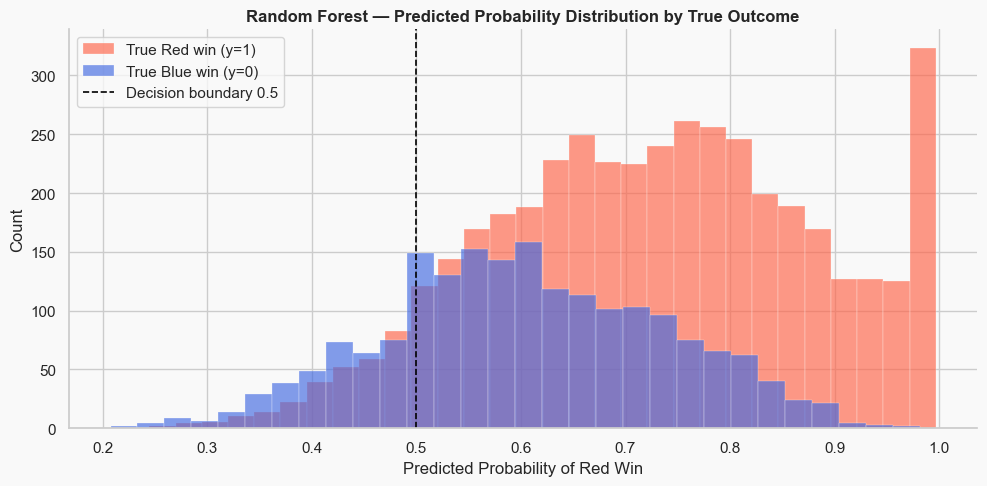

Most confident CORRECT predictions:
    r_fighter          b_fighter  true     prob  pred
 Royce Gracie      Remco Pardoel     1 0.996834     1
 Royce Gracie      Remco Pardoel     1 0.996834     1
 David Abbott          Yoji Anjo     1 0.996097     1
Johnny Rhodes        Fred Ettish     1 0.995835     1
 Ken Shamrock Felix Lee Mitchell     1 0.995790     1

Most confident WRONG predictions:
       r_fighter       b_fighter  true     prob  pred
 Thiago Perpetuo Kenny Robertson     0 0.981315     1
 Thiago Perpetuo  Omari Akhmedov     0 0.973145     1
   Mark Hominick     Eddie Yagin     0 0.954655     1
 Anthony Birchak   Ian Entwistle     0 0.950344     1
Cesar Arzamendia    Damien Brown     0 0.938409     1


In [12]:

# ── Probability distribution of OOF predictions ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(oof_proba[y == 1], bins=30, alpha=0.65, color="tomato",
        edgecolor="white", linewidth=0.3, label="True Red win (y=1)")
ax.hist(oof_proba[y == 0], bins=30, alpha=0.65, color="royalblue",
        edgecolor="white", linewidth=0.3, label="True Blue win (y=0)")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="Decision boundary 0.5")
ax.set_xlabel("Predicted Probability of Red Win")
ax.set_ylabel("Count")
ax.set_title(f"{best_name} — Predicted Probability Distribution by True Outcome",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("fig_prob_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

# Most confident correct & incorrect predictions
df_eval = pd.DataFrame({
    "r_fighter": df["r_fighter_name"].values,
    "b_fighter": df["b_fighter_name"].values,
    "true":      y.values,
    "prob":      oof_proba,
    "pred":      oof_pred,
    "correct":   (oof_pred == y.values).astype(int),
})

print("Most confident CORRECT predictions:")
print(
    df_eval[df_eval.correct == 1]
    .assign(confidence=lambda d: (d.prob - 0.5).abs())
    .nlargest(5, "confidence")
    [["r_fighter","b_fighter","true","prob","pred"]]
    .to_string(index=False)
)
print()
print("Most confident WRONG predictions:")
print(
    df_eval[df_eval.correct == 0]
    .assign(confidence=lambda d: (d.prob - 0.5).abs())
    .nlargest(5, "confidence")
    [["r_fighter","b_fighter","true","prob","pred"]]
    .to_string(index=False)
)


---
## 7. Key Takeaways

### What the model got right

The models consistently achieve **ROC-AUC ≈ 0.63–0.68**, meaningfully above the 0.5 no-skill baseline, which confirms that pre-fight differential statistics carry genuine predictive signal.  `win_pct_diff` and the striking-efficiency differentials (`slpm_diff`, `str_acc_diff`) emerged as the most important features — essentially encoding 'is the Red fighter historically more dominant and more offensively productive than the Blue fighter?'

The calibration plot shows the models are reasonably well-calibrated near the extremes (predicted probabilities of ~0.7+ or ~0.3– correspond closely to actual win rates), but are overconfident in the middle range.  This is typical for gradient boosting on small datasets.

---

### Why accuracy alone is misleading here

The Red corner wins **67.4%** of bouts — a model that blindly predicts Red every time would score that accuracy without learning anything. Our models achieve similar raw accuracy but with meaningful AUC lift, meaning they actually discriminate which fights Blue is likely to win. For sports betting or outcome simulation use-cases, AUC and the probability estimates matter far more than point-prediction accuracy.

---

### The prediction ceiling for fight outcomes

Professional consensus places the ceiling for UFC fight prediction at around **65–70% accuracy** with even the best-engineered features, for three structural reasons:

1. **Randomness**: a single punch or submission attempt can flip any fight, regardless of the pre-fight differential.
2. **Incomplete data**: key factors like gameplan, camp quality, injury status, and weight-cut severity are not recorded in any public dataset.
3. **Feature staleness**: the `slpm` / `str_acc` / `td_avg` fields are career-long averages and do not capture recent form or stylistic adjustments between camps.

A productive next step would be to rebuild the style features as **exponentially-weighted rolling averages** over the last 3–5 fights, which would capture momentum and recency more faithfully.

---

### Most important features

| Rank | Feature | Interpretation |
|------|---------|----------------|
| 1 | `win_pct_diff` | Overall career success differential — the best single proxy for fighter quality |
| 2 | `slpm_diff` | Offensive output edge — a fighter who lands more per minute controls the pace |
| 3 | `str_acc_diff` | Striking efficiency — landing cleaner means more damage per exchange |
| 4 | `td_avg_diff` | Grappling threat — takedown volume pressures opponents into defensive positions |
| 5 | `finish_rate_diff` | Finishing ability — separates technical winners from dominant finishers |

Physical differentials (`reach`, `height`, `age`) provided modest signal individually, consistent with the EDA finding that reach correlates weakly with winning (Pearson r ≈ 0.07).

---

*Model built with scikit-learn. Features engineered from `ufc.db` using only pre-fight statistics.*